In [ ]:
!git clone https://github.com/HelenZaya/Project-3-Car-TypeBrand-Recognition-System-11-21.git

In [ ]:
!git clone https://github.com/nerminnuraydogan/car-brand-detection.git

In [ ]:
!pip install ultralytics

In [ ]:
!curl -L -o yolo-obj_final.weights "https://drive.google.com/uc?export=download&id=1Nf4yVn1RzoCSev8CQeU27szYYk8KWFNE"

In [ ]:
!curl -O https://cdn.pixabay.com/photo/2023/07/19/12/16/car-8136751_960_720.jpg && mv car-8136751_960_720.jpg car-brand-detection/data

In [ ]:
import os

file_path = 'yolo-obj_final.weights'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"Current size of '{file_path}': {file_size / (1024 * 1024):.2f} MB ({file_size} bytes)")
    with open(file_path, 'r', encoding='latin-1') as f:
        print("First 5 lines of the file:")
        for i, line in enumerate(f):
            if i >= 5: break
            print(line.strip())
else:
    print(f"File '{file_path}' not found.")

In [ ]:
!pip install gdown

In [ ]:
# Use gdown to download the file from Google Drive
# The ID is extracted from the shareable link: https://drive.google.com/file/d/1Nf4yVn1RzoCSev8CQeU27szYYk8KWFNE/view
!gdown --id 1Nf4yVn1RzoCSev8CQeU27szYYk8KWFNE -O yolo-obj_final.weights

In [ ]:
import os

file_path = 'yolo-obj_final.weights'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"New size of '{file_path}': {file_size / (1024 * 1024):.2f} MB ({file_size} bytes)")
else:
    print(f"File '{file_path}' still not found after gdown attempt.")

In [ ]:
import os

# List files and directories in the current working directory
print(os.listdir('.'))

# Additionally, provide a more user-friendly output for files and directories
print("\n--- Files and Directories ---")
for item in os.listdir('.'):
    if os.path.isfile(item):
        print(f"File: {item}")
    elif os.path.isdir(item):
        print(f"Directory: {item}")

Time took: 1.75s


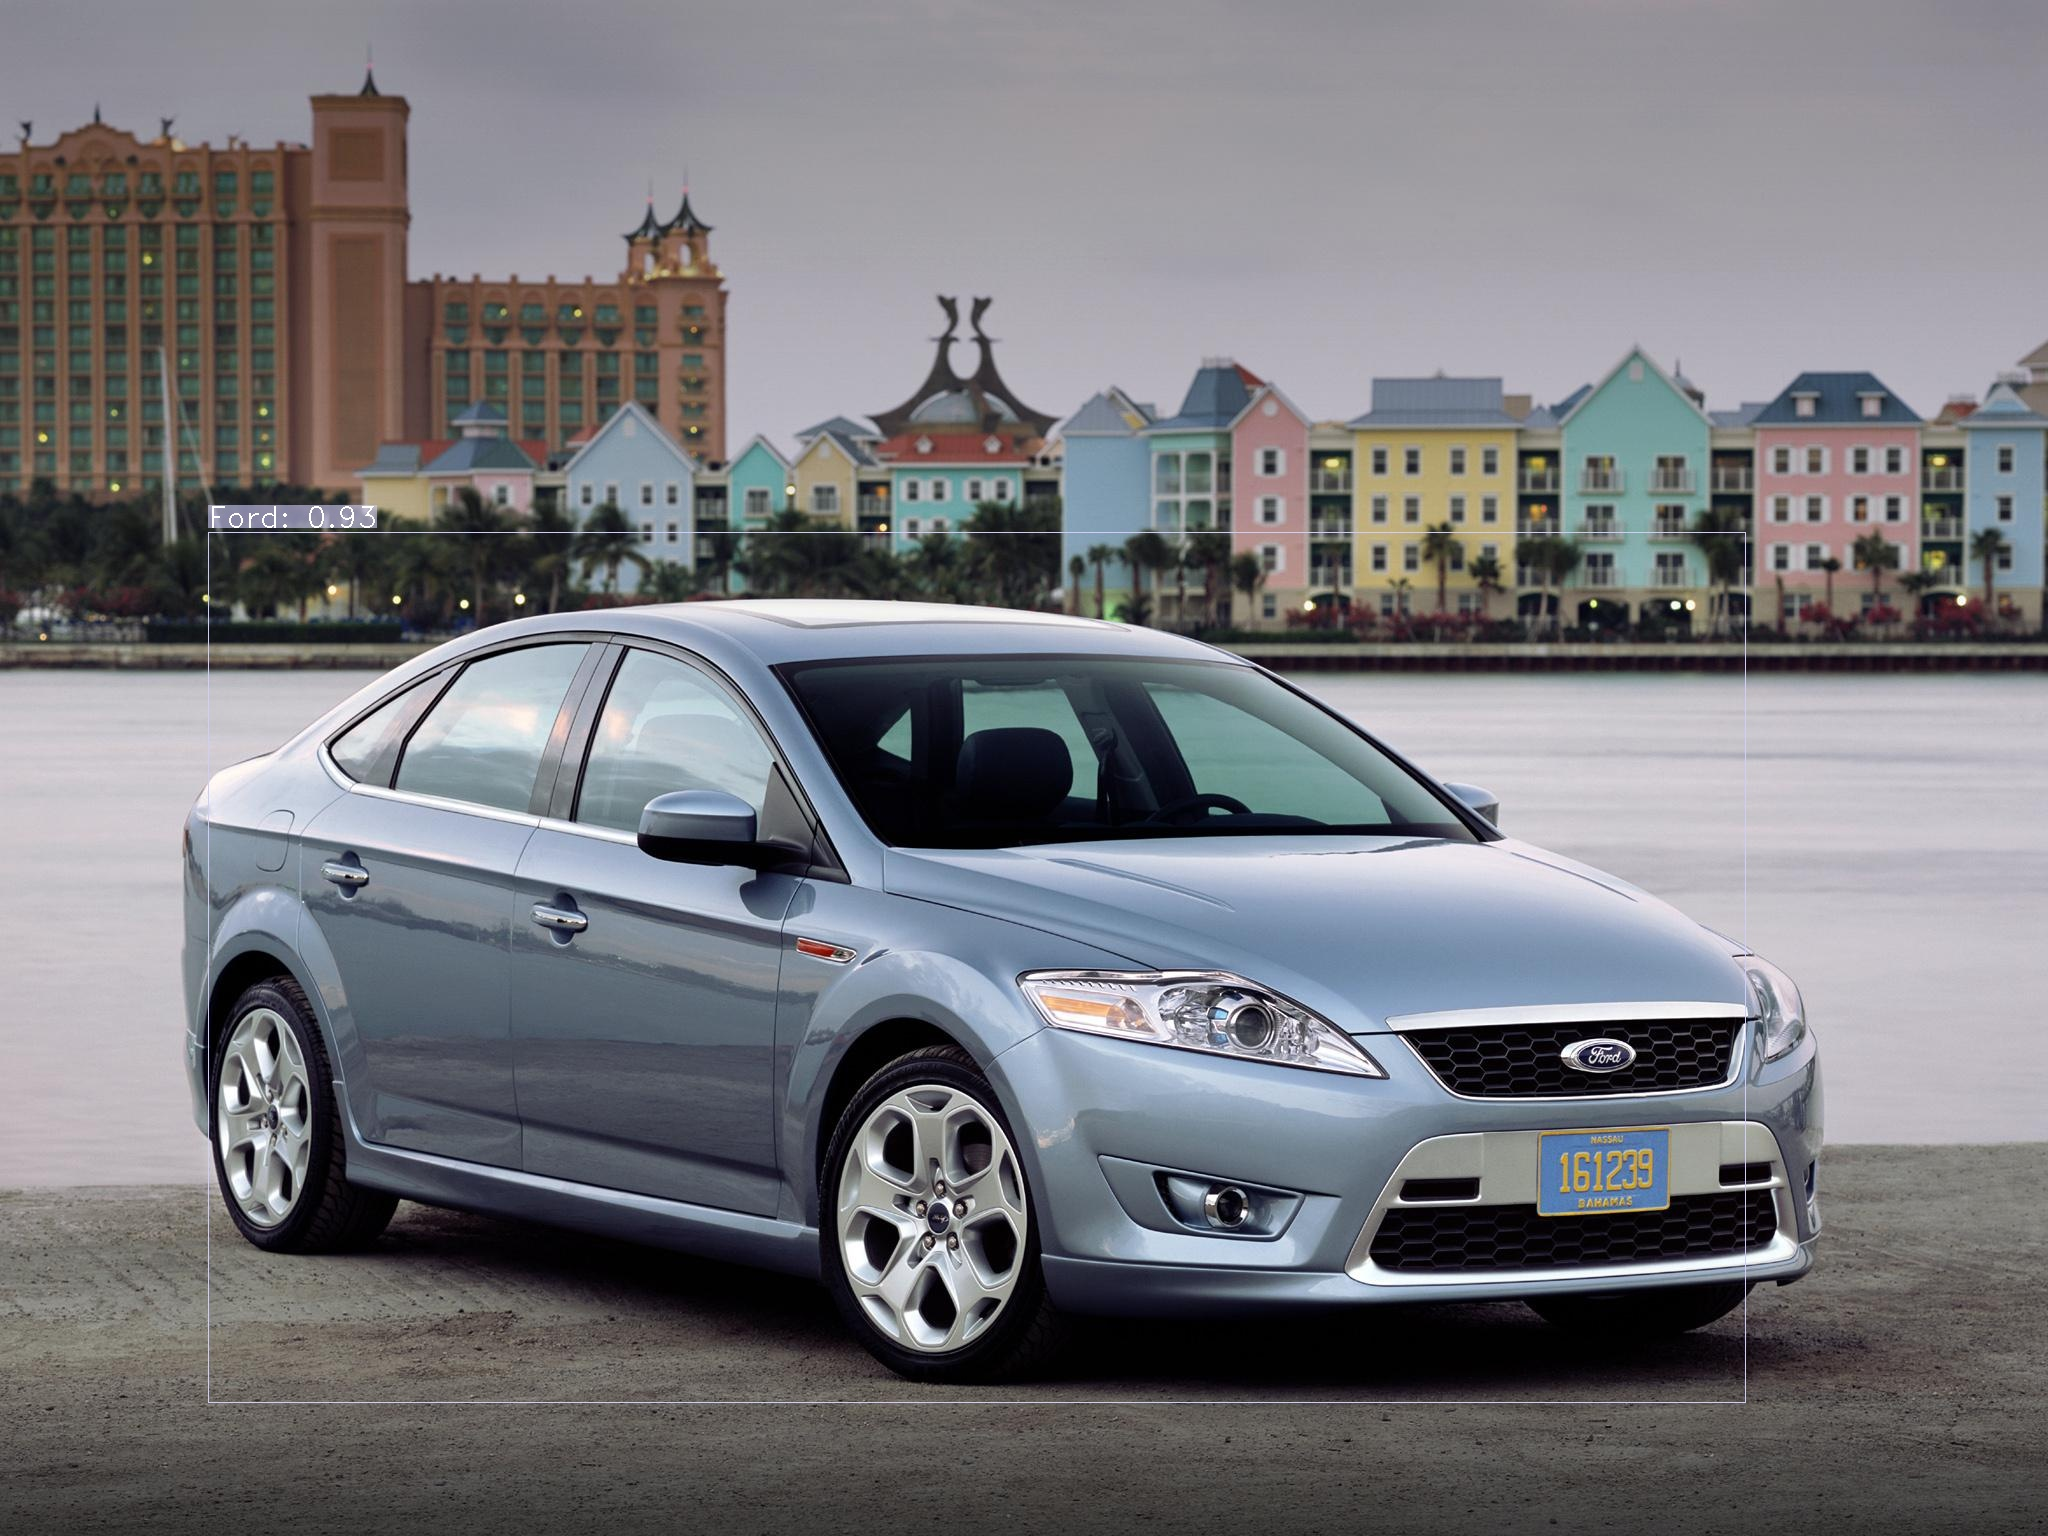

In [ ]:
import cv2
import numpy as np
from IPython.display import Image, display
import time
import sys
import os

# adapted from https://www.pyimagesearch.com/2018/11/12/yolo-object-detection-with-opencv/


# Minimum probability to filter weak detections.
# a default value of 50% (0.5 ),
# you should feel free to experiment with this value.
CONFIDENCE = 0.5
# non-maxima suppression threshold with a default value of 0.5 .
SCORE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

# the neural network configuration
config_path = "car-brand-detection/cfg/yolo-obj.cfg"

# the YOLO net weights file
weights_path = "yolo-obj_final.weights" # This was already downloaded to the root directory.

# loading all the class labels (objects)
LABELS = open("car-brand-detection/data/obj.names").read().strip().split("\n")

# generating colors for each object for later plotting
COLORS = np.random.randint(0, 255, size=(len(LABELS), 3), dtype="uint8")

# load the YOLO network
net = cv2.dnn.readNetFromDarknet(config_path, weights_path)


# path name to the image
#EXMP:TESTED -> path_name = "car-brand-detection/data/chrysler.jpg"
#EXMP:TESTED SUCCESSFULY-> path_name = "/content/Project-3-Car-TypeBrand-Recognition-System-11-21/Benz/000002.jpeg"
#EXMP:TESTED SUCCESSFULY-> path_name = "/content/Project-3-Car-TypeBrand-Recognition-System-11-21/Ford/000025.jpg"
#path_name = "car-brand-detection/data/car-8136751_960_720.jpg"
path_name = "/content/Project-3-Car-TypeBrand-Recognition-System-11-21/Ford/000025.jpg"
# arrange filenames to later save the deteceted object image
# jfif extension may cause problems, try jpg format
file_name = os.path.basename(path_name)
filename, ext = file_name.split(".")

# load the input image and get its spatial dimensions
image = cv2.imread(path_name)
h, w = image.shape[:2]

# 4D blob
# construct a blob from the input image and then perform a forward
# pass of the YOLO object detector, giving the our bounding boxes and
# associated probabilities
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)

# sets the blob as the input of the network
net.setInput(blob)

# get all the layer names
ln = net.getLayerNames()

# determine only the *output* layer names that we need from YOLO to detect
# Older OpenCV versions might return a scalar or a list of scalars. Ensure it's treated as a flat list of indices.
ln = [ln[i - 1] for i in net.getUnconnectedOutLayers().flatten()]



# feed forward (inference) and get the network output
# measure how much it took in seconds
start = time.perf_counter()
layer_outputs = net.forward(ln)
time_took = time.perf_counter() - start
print(f"Time took: {time_took:.2f}s")

# initialize our lists of detected bounding boxes, confidences, and
# class IDs, respectively
boxes, confidences, class_ids = [], [], []


# boxes : The bounding boxes around the object.
# confidences : The confidence value that YOLO assigns to an object.
# classIDs : The detected object’s class label.

# Lower confidence values indicate that the object might not be what the network thinks it is.
# Remember from the constans above that it will filter out the objects that don’t meet the 0.5 threshold.


# loop over each of the layer outputs
for output in layer_outputs:

    # loop over each of the object detections
    for detection in output:
        # extract the class id (label) and confidence (as a probability) of
        # the current object detection
        scores = detection[5:]
        class_id = np.argmax(scores)    # the most probable class id
        confidence = scores[class_id]

        # discard weak predictions by ensuring the detected
        # probability is greater than the minimum probability
        if confidence > CONFIDENCE:
            # scale the bounding box coordinates back relative to the
            # size of the image, keeping in mind that YOLO actually
            # returns the center (x, y)-coordinates of the bounding
            # box followed by the boxes' width and height
            box = detection[:4] * np.array([w, h, w, h])
            (centerX, centerY, width, height) = box.astype("int")

            # use the center (x, y)-coordinates to derive the top and
            # and left corner of the bounding box
            x = int(centerX - (width / 2))
            y = int(centerY - (height / 2))

            # update our list of bounding box coordinates, confidences,
            # and class IDs
            boxes.append([x, y, int(width), int(height)])
            confidences.append(float(confidence))
            class_ids.append(class_id)



# Applying non-maxima suppression suppresses significantly overlapping bounding boxes,
# keeping only the most confident ones.

# perform the non maximum suppression given the scores defined before
idxs = cv2.dnn.NMSBoxes(boxes, confidences, SCORE_THRESHOLD, IOU_THRESHOLD)

# define visual content values for drawing bounding box around the detected object
font_scale = 1
font_thickness = 1
font_color = (255, 255, 255)

thickness = 1

# ensure at least one detection exists
if len(idxs) > 0:
    # loop over the indexes we are keeping
    for i in idxs.flatten():
        # extract the bounding box coordinates
        x, y = boxes[i][0], boxes[i][1]
        w, h = boxes[i][2], boxes[i][3]

        # draw a bounding box rectangle and label on the image
        color = [int(c) for c in COLORS[class_ids[i]]]
        cv2.rectangle(image, (x, y), (x + w, y + h), color=color, thickness=thickness)
        text = f"{LABELS[class_ids[i]]}: {confidences[i]:.2f}"
        # calculate text width & height to draw the transparent boxes as background of the text
        (text_width, text_height) = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, fontScale=font_scale, thickness=thickness)[0]
        text_offset_x = x
        text_offset_y = y - 5
        box_coords = ((text_offset_x, text_offset_y), (text_offset_x + text_width + 2, text_offset_y - text_height))
        overlay = image.copy()
        cv2.rectangle(overlay, box_coords[0], box_coords[1], color=color, thickness=cv2.FILLED)

        # add opacity (transparency to the box)
        image = cv2.addWeighted(overlay, 0.6, image, 0.4, 0)
        # now put the text (label: confidence %)
        cv2.putText(image, text, (x, y - 5), cv2.FONT_HERSHEY_DUPLEX,
            fontScale=font_scale, color=font_color, thickness=font_thickness)

# display image
# cv2.imshow("image", image) # This line will not work in Colab environment. Remove it.
# if cv2.waitKey(0) == ord("q"):
#     pass

# save to a file
cv2.imwrite(filename + "_yolov4." + ext, image)
display(Image(filename=filename + "_yolov4." + ext))